In [18]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

crime_data = pd.read_csv('../data/raw_2021-2024.csv')

crime_data = crime_data.dropna(subset=['Latitude', 'Longitude'])

neighborhoods = gpd.read_file('../data/neighborhoods/Neighborhoods.shp')


C:\Users\User\AppData\Local\Temp\ipykernel_13860\4235540223.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  crime_data = pd.read_csv('../data/raw_2021-2024.csv')


In [3]:
# Aggregate crime data by neighborhood
crime_counts = crime_data.groupby("Neighborhood")["IncidentNum"].count().reset_index(name="CrimeCount")

In [16]:
# Merge crime data with the shapefile
neighborhoods_with_crime = neighborhoods.merge(crime_counts, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods_with_crime["CrimeCount"] = neighborhoods_with_crime["CrimeCount"].fillna(0)

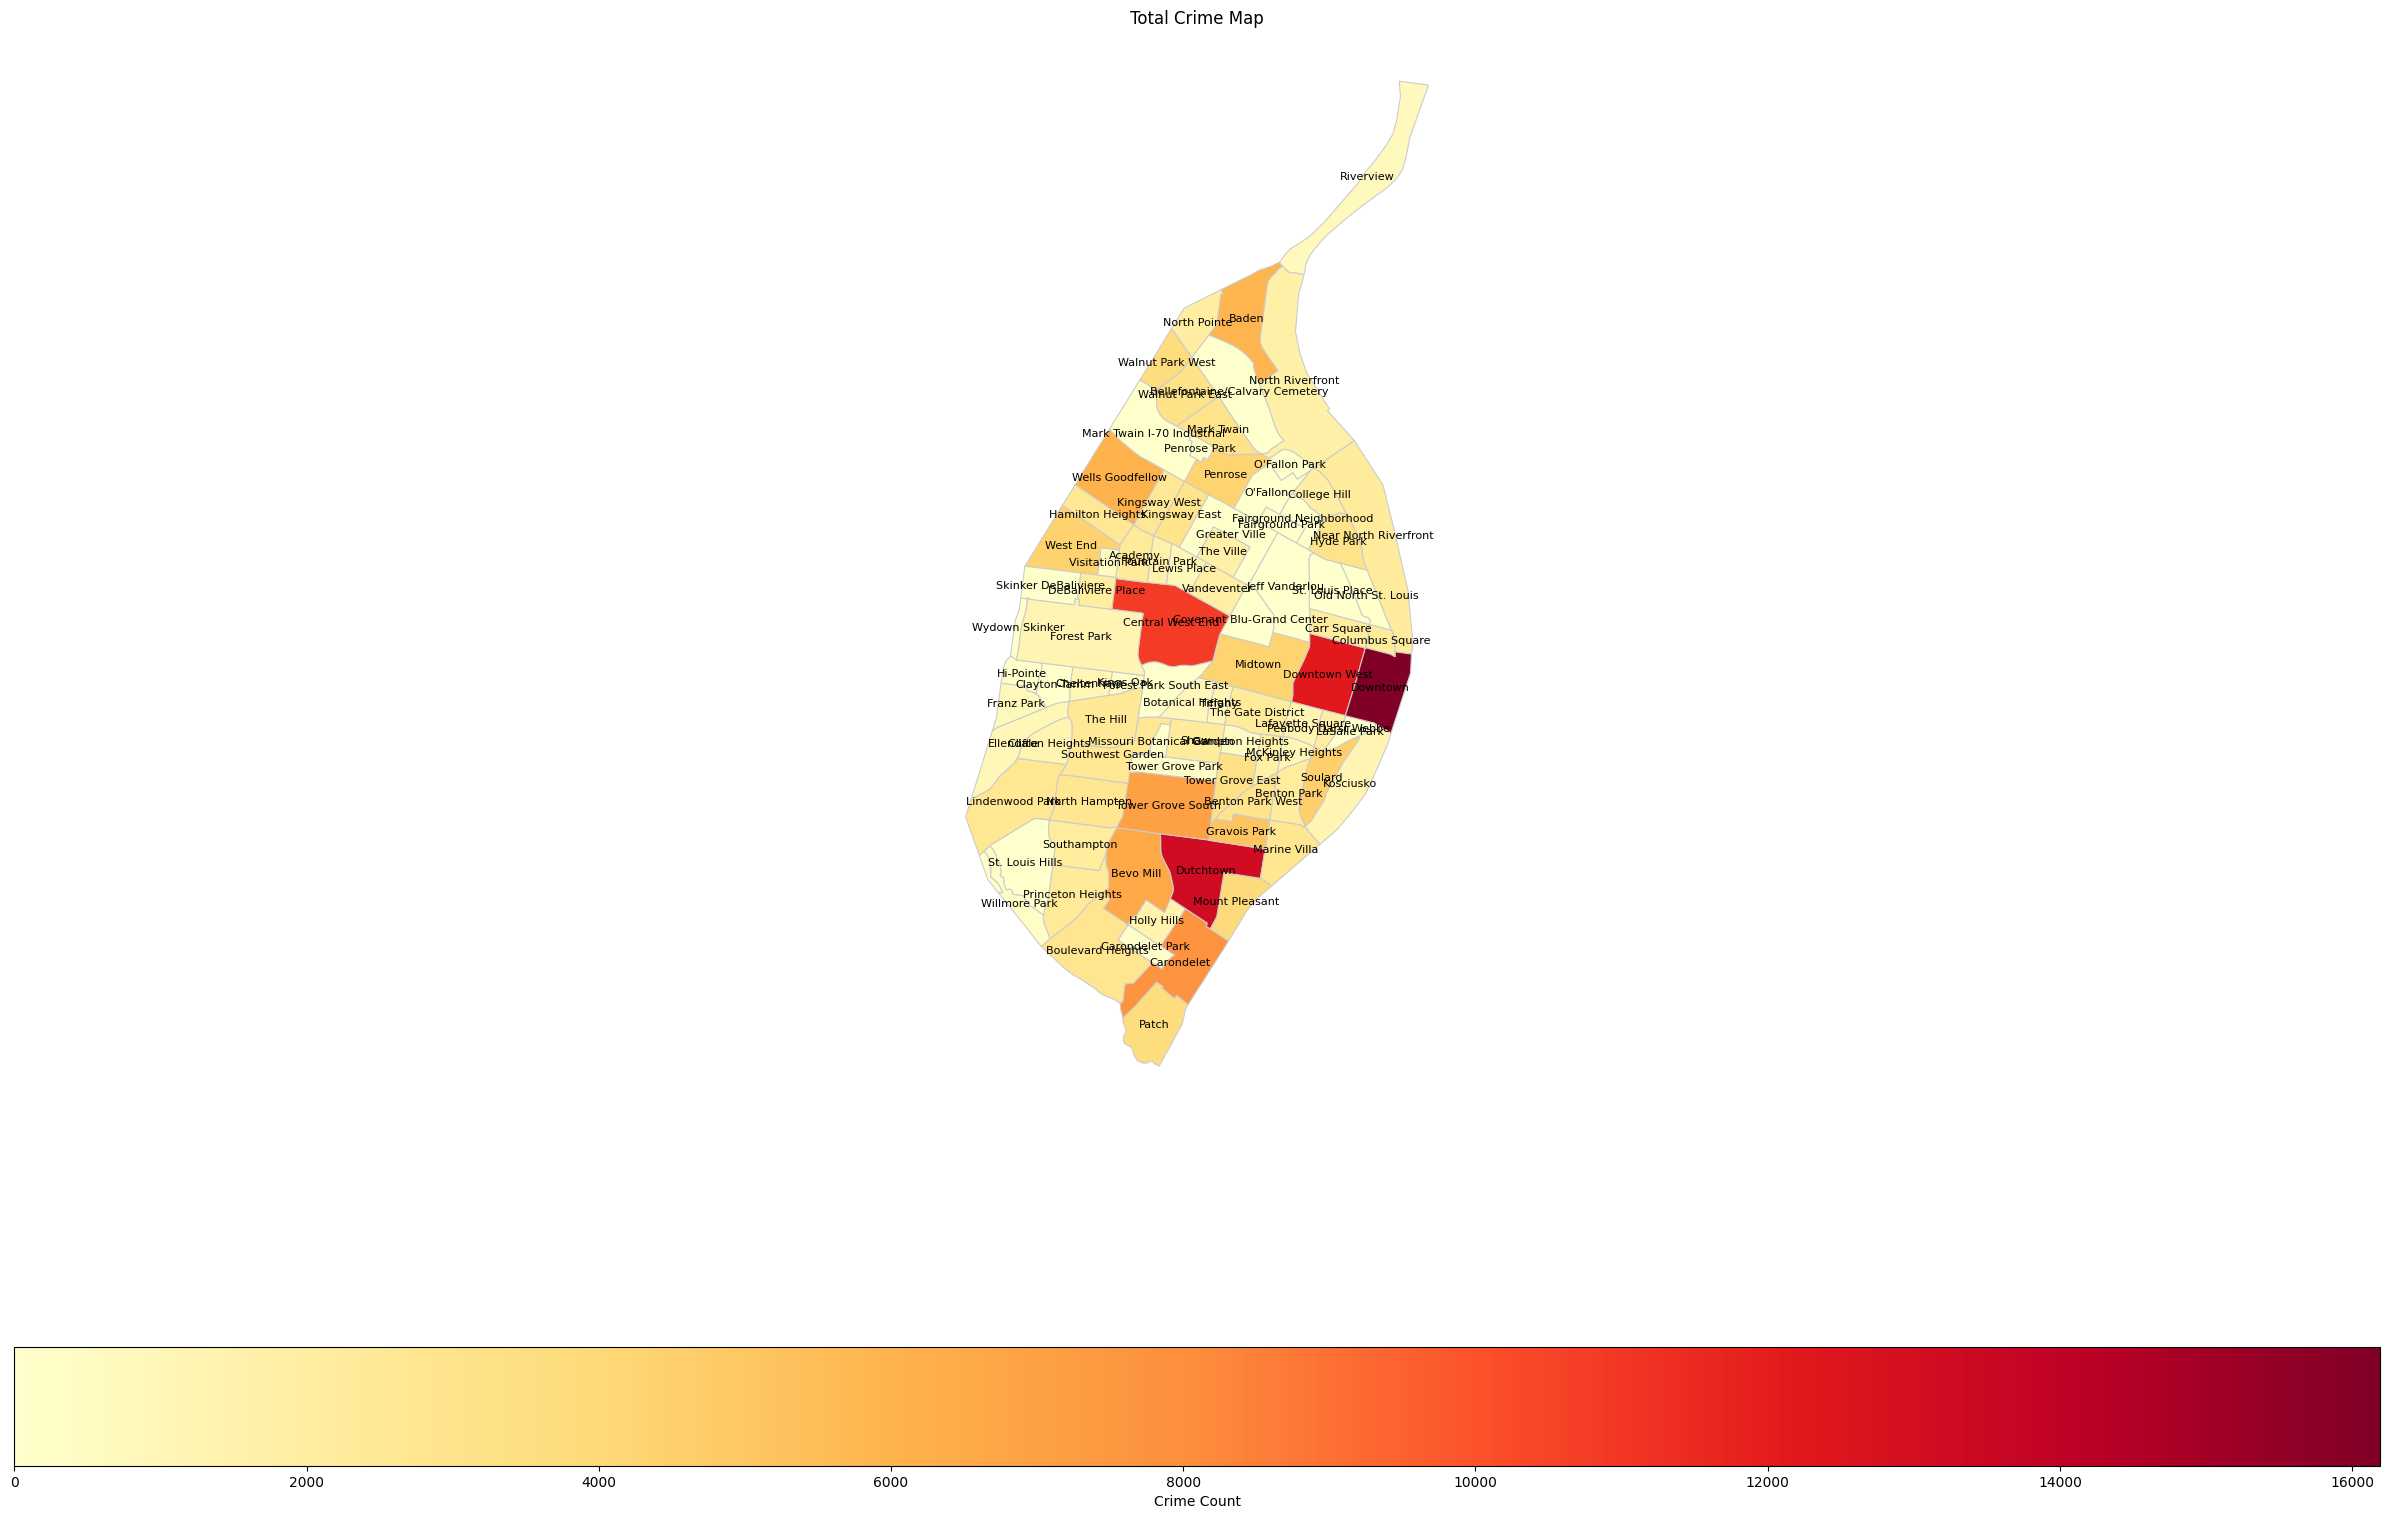

In [22]:
def create_chloropleth(dataframe, title):
    # Create the choropleth map
    fig, ax = plt.subplots(figsize=(24, 16))
    dataframe.plot(column="CrimeCount", cmap="YlOrRd", linewidth=0.8, edgecolor="0.8", ax=ax, legend=True, legend_kwds={"label": "Crime Count", "orientation": "horizontal"})
    
    # Add neighborhood labels
    for idx, row in dataframe.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row["NHD_NAME"], fontsize=8, ha="center", va="center")
    
    ax.set_title(title)
    ax.axis("off")
    
    plt.tight_layout()
    plt.show()

create_chloropleth(neighborhoods_with_crime, "Total Crime Map")

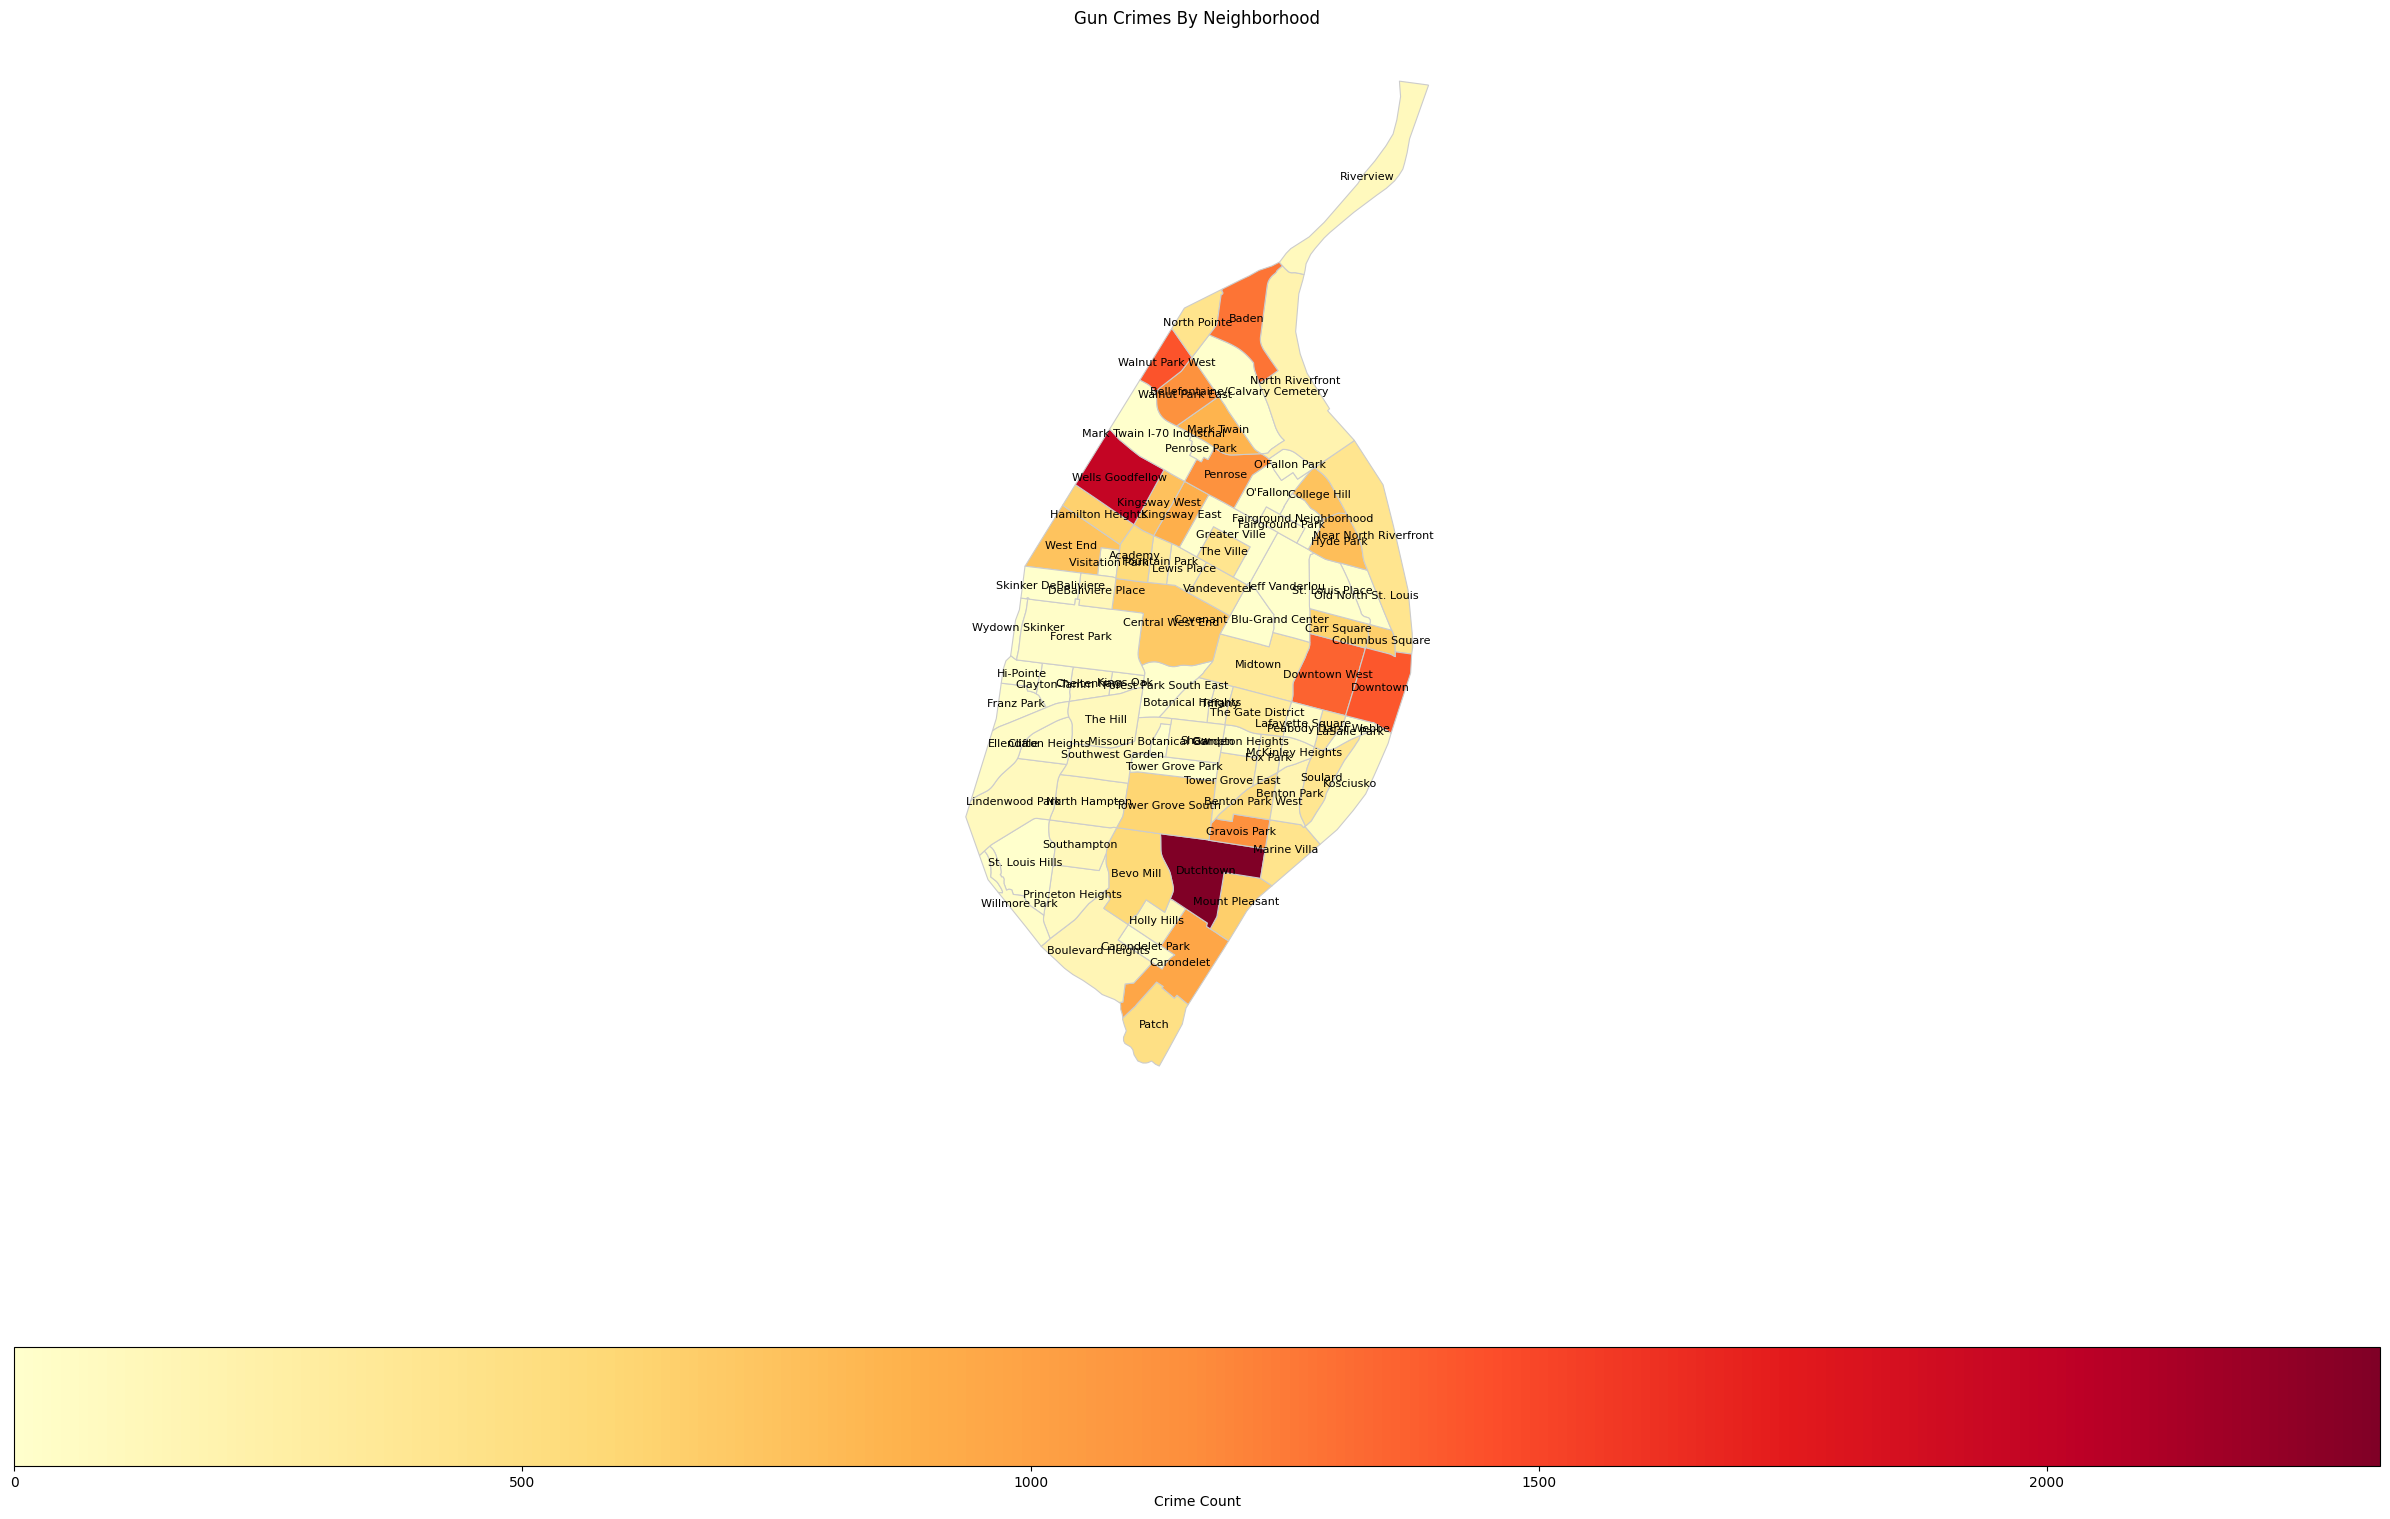

In [25]:
gun_crime_data = crime_data[crime_data['FirearmUsed'] == 'Yes']

gun_crime_counts = gun_crime_data.groupby("Neighborhood")["IncidentNum"].count().reset_index(name="CrimeCount")

neighborhoods_with_gun_crime = neighborhoods.merge(gun_crime_counts, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods_with_gun_crime["CrimeCount"] = neighborhoods_with_gun_crime["CrimeCount"].fillna(0)

create_chloropleth(neighborhoods_with_gun_crime, "Gun Crimes By Neighborhood 2021-2024")